**10. Tiempo por encima de cierta altitud**

In [ ]:
import numpy as np

# Datos del problema
R_Tierra = 6378.0  # Radio promedio de la Tierra (km)
mu = 3.986e14  # mu de la Tierra (m³/s²)
R_perigeo = 250 + R_Tierra  # km
R_apogeo = 650 + R_Tierra  # km
Altura_límite = 450  # km
R_límite = Altura_límite + R_Tierra  # km

# Elementos orbitales necesarios (a, e, E, M)
a_km = (R_perigeo + R_apogeo) / 2.0  # Semieje mayor (km)
a_m = a_km * 1000.0  # Semieje mayor (m)
e = (R_apogeo - R_perigeo) / (R_apogeo + R_perigeo)  # Excentricidad

# cos(E) = (1 - r/a) / e
cos_E = (1.0 - (R_límite / a_km)) / e
cos_E = np.clip(cos_E, -1.0, 1.0)  # Evita errores de redondeo
E1 = np.arccos(cos_E)  # Ascenso
E2 = 2 * np.pi - E1  # Descenso

# M = E - e * sin(E)
M1 = E1 - e * np.sin(E1)
M2 = E2 - e * np.sin(E2)
# Intervalo de M transcurrido por encima de la altitud límite
delta_M = M2 - M1

# 3ra Ley de Kepler
P_s = 2 * np.pi * np.sqrt((a_m**3) / mu)  # Periodo orbital (s)
P_m = P_s / 60.0  # Periodo orbital (min)

# Fracción del periodo
Fracción_P = delta_M / (2 * np.pi)
t_alt_s = Fracción_P * P_s  # Tiempo transcurrido por encima de la altitud límite (s)
t_alt_m = t_alt_s / 60.0  # Tiempo transcurrido por encima de la altitud límite (min)

print(f"Semieje mayor (a): {a_km:.2f} km")
print(f"Excentricidad (e): {e:.5f}")
print(f"Periodo orbital total: {P_m:.2f} minutos ({P_s:.1f} s)")
print("-" * 40)
print(f"Fracción del periodo por encima de {Altura_límite} km: {Fracción_P:.5f} ({Fracción_P*100:.2f}%)")
print(f"Tiempo neto por encima de la altitud: {t_alt_m:.2f} minutos ({t_alt_s:.1f} s)")

Semieje mayor (a): 6828.00 km
Excentricidad (e): 0.02929
Periodo orbital total: 93.58 minutos (5615.0 s)
----------------------------------------
Fracción del periodo por encima de 450 km: 0.50932 (50.93%)
Tiempo neto por encima de la altitud: 47.66 minutos (2859.9 s)


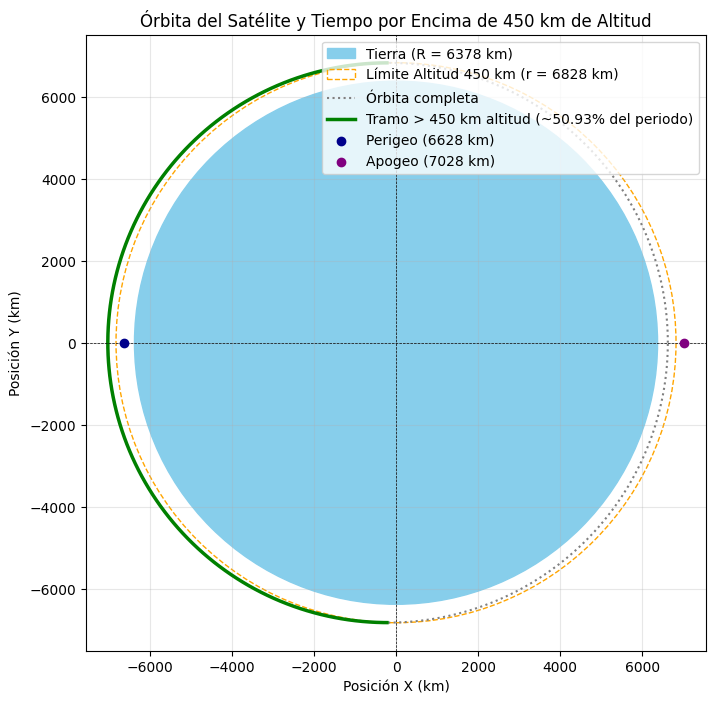

In [ ]:
import matplotlib.pyplot as plt

c = a_km * e  # Distancia semifocal

E_vals = np.linspace(0, 2 * np.pi, 500)
x_elipse = a_km * np.cos(E_vals)
y_elipse = a_km * np.sqrt(1 - e**2) * np.sin(E_vals)

# Mover La Tierra a (0,0) y el centro de la elipse a (-c,0)
x_órbita = x_elipse - c
y_órbita = y_elipse

# Distancia radial desde el origen para cada punto de la órbita
r_vals = np.sqrt(x_órbita**2 + y_órbita**2)
a_límite = r_vals >= R_límite

plt.figure(figsize=(8, 8))
earth_circle = plt.Circle((0, 0), R_Tierra, color='skyblue', label='Tierra (R = 6378 km)')
plt.gca().add_patch(earth_circle)
limit_circle = plt.Circle((0, 0), R_límite, color='orange', linestyle='--', fill=False,
                          label=f'Límite Altitud {Altura_límite} km (r = {R_límite:.0f} km)')
plt.gca().add_patch(limit_circle)
plt.plot(x_órbita, y_órbita, color='gray', linestyle=':', label='Órbita completa')
plt.plot(x_órbita[a_límite], y_órbita[a_límite], color='green', linewidth=2.5,
         label='Tramo > 450 km altitud (~50.93% del periodo)')
plt.scatter([-R_perigeo], [0], color='darkblue', zorder=5, label=f'Perigeo ({R_perigeo:.0f} km)')
plt.scatter([R_apogeo], [0], color='purple', zorder=5, label=f'Apogeo ({R_apogeo:.0f} km)')

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Órbita del Satélite y Tiempo por Encima de 450 km de Altitud')
plt.xlabel('Posición X (km)')
plt.ylabel('Posición Y (km)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.show()